In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
os.chdir("..")

from utils import clean_utils

En cada partida de *League of Legends*, cada uno de los jugadores tiene un rol asignado: "Top", "Jungle", "Mid", "Bottom" y "Support".

Cada rol tiene diferentes repsonsabilidades durante la partida. Por ejemplo:
- Un "Top" tiene como objetivo defender a su equipo, por lo que tendrá más daño recibido.
- Un "Bottom" tiene como objetivo hacer mucho daño al equipo enemigo, por lo que tendrá más daño realizado.
- Un "Support" tiene como objetivo dar visión a su equipo, por lo que tendrá más puntos de visión.
- ...

Con esto en mente, vamos a analizar las estadísticas de las partidas de cada rol para ver dónde se parece y dónde difieren.

In [26]:
individual_stats = pd.read_csv("datasets/individual_stats.csv", sep=",")
rank_tbl = pd.read_csv("datasets/RankTbl.csv", sep=",")
individual_stats["Lane"].value_counts()

Lane
BOTTOM     105897
JUNGLE      88370
MIDDLE      85187
TOP         80323
UTILITY     53599
NONE        22536
SUPPORT        12
Name: count, dtype: int64

Podemos ver que hay 2 errores en cómo estñan recogidos los datos:
- Algunos no tienen rol directamente --> Los eliminamos del análisis.
- El rol de "Support" está divido en "Support" y "Utility" --> Unificamos en "Support".

In [9]:
role_df = individual_stats[individual_stats["Lane"] != "NONE"]
role_df["Lane"] = role_df["Lane"].replace("UTILITY", "SUPPORT")
role_df["Lane"].value_counts()

Lane
BOTTOM     105897
JUNGLE      88370
MIDDLE      85187
TOP         80323
SUPPORT     53611
Name: count, dtype: int64

Comenzamos con el análisis. PRimero cogemos las métricas que vamos a comparar y después calculamos la media de cada métrica para cada rol (*groupby()*)

In [11]:
metrics = ["kills", "deaths", "assists", "DmgDealt", "DmgTaken", "TurretDmgDealt", "TotalGold", "MinionsKilled", "visionScore"]

role_means = role_df.groupby("Lane")[metrics].mean()  # Mean per role for each metric


Ahora que las tenemos las vamos a visualizar. Como son 5 roles y hay que comparar varias estadísticas diferentes, vamos a utilizar un gráfico de radar. 
- Cada punta de la estrella será una métrica, así podemos comparar visualmente en qué se centra cada rol.
- Como tiene que tener la misma escala, también normalizamos todas las medias entre 0 y 1. Aunque perdamos información, mantenemos las proporciones, que es lo que queremos ver. 
    - Adicionalmente, pongo un suelo de 0.2 porque todos los roles siempre hacen un mínimo de todo, pero al normalizar los valores muy bajos colapsan a 0 y no es representativo.

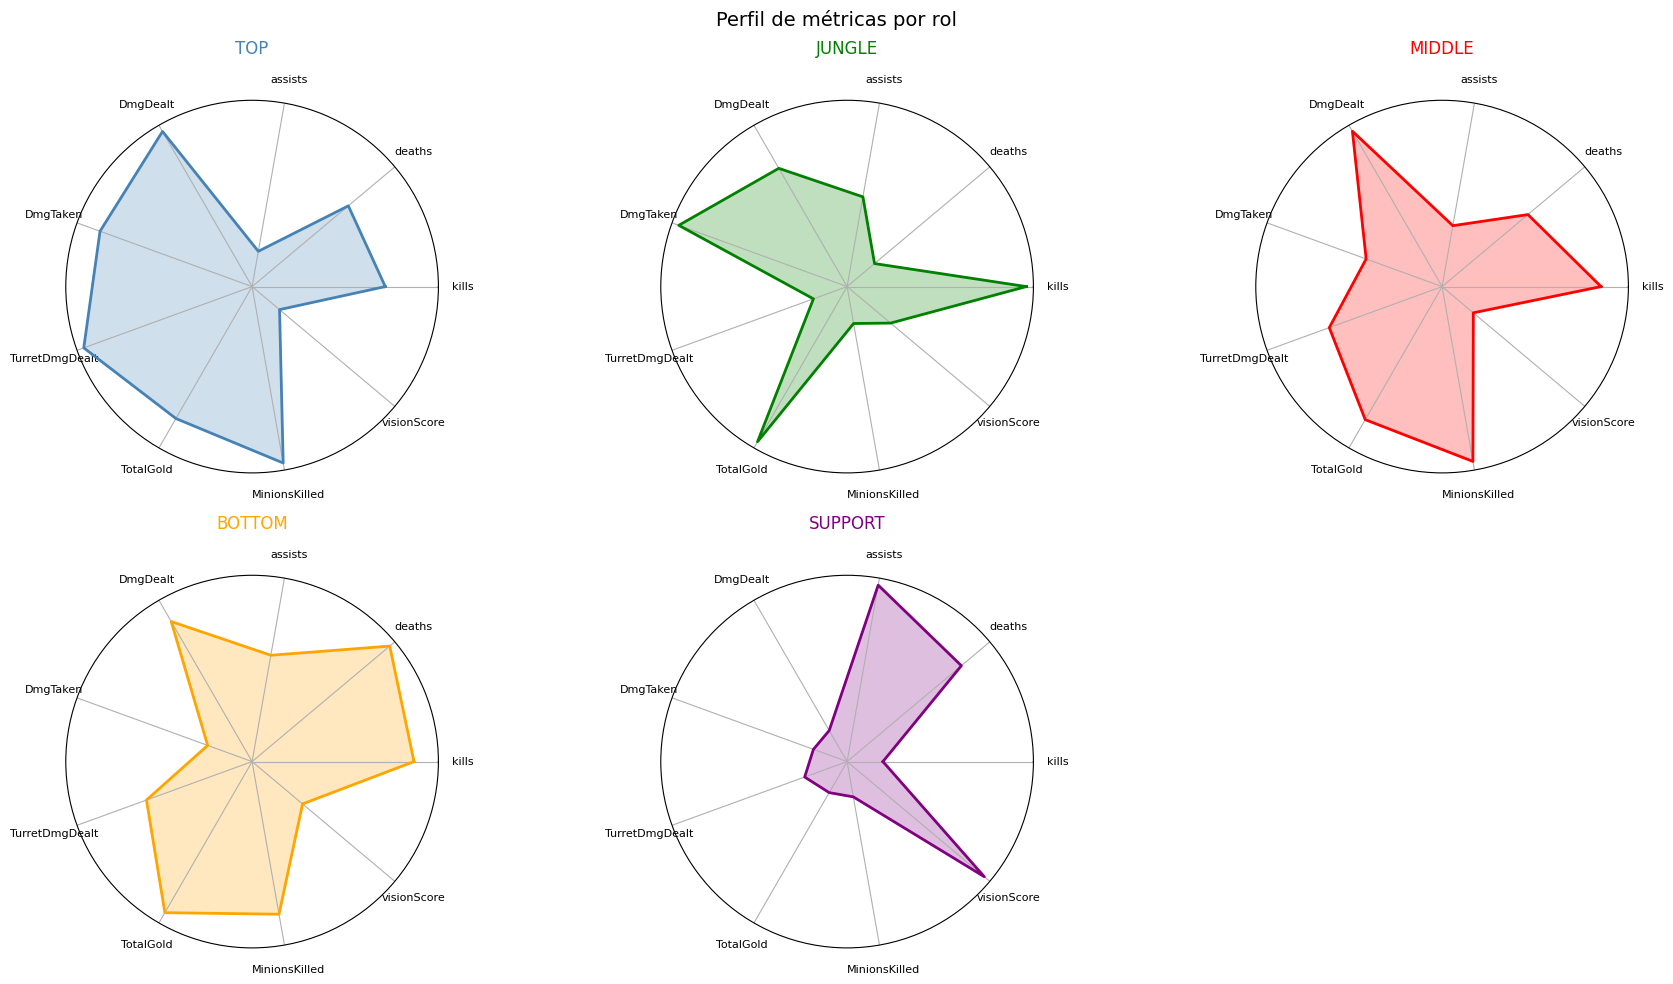

In [25]:
role_normalized = (role_means - role_means.min()) / (role_means.max() - role_means.min())  # Normalize 0-1
role_normalized = role_normalized * 0.8 + 0.2  # rescale to 0.2-1.0 instead of 0-1 so it does not collapse low values to 0

# Radar chart
labels = metrics
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

colors = {"TOP": "steelblue", "JUNGLE": "green", "MIDDLE": "red", "BOTTOM": "orange", "SUPPORT": "purple"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw=dict(polar=True))

roles_order = ["TOP", "JUNGLE", "MIDDLE", "BOTTOM", "SUPPORT"]
axes_flat = axes.flatten()

for ax, role in zip(axes_flat, roles_order):
    row = role_normalized.loc[role]
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=colors[role], linewidth=2)
    ax.fill(angles, values, color=colors[role], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=8)
    ax.set_yticks([])
    ax.set_title(role, size=12, pad=15, color=colors[role])
    ax.tick_params(pad=7)

axes_flat[5].set_visible(False)  # Hide the 6th empty subplot

fig.suptitle("Perfil de métricas por rol", fontsize=14)
plt.tight_layout()

Podemos ver que cada tol presenta una forma claramente distinta al resto.
- Los más parecidos son "Mid" y "Bottom" ya que en ambos roles se suelen jugar personajes con rango cuya función es hacer daño.
- "Top" y "Jungle" son los roles que más daño reciben "DmgTaken" ya que juegan personajes a melee que tienden a recibir más ataques al estar en medio de la acción. 
- "Support" es el más diferente a todos. Destaca en "visionScore" y en "assists". Esto tiene sentido ya que su tarea es ayudar a los otros personajes a conseguir oro, hacer daño, ...

Ahora que sabemos la diferencias entre roles, vamos a ver si la distribución de estadísticas cambia respecto al rango.

In [54]:
metrics_style = ["kills", "deaths", "assists", "visionScore", "MinionsKilled", "TurretDmgDealt"]
rank_order = ["Iron", "Bronze", "Silver", "Gold", "Platinum", "Emerald", "Diamond", "Master", "Grandmaster", "Challenger"]

role_rank_df = role_df[role_df["RankFk"] != 0]  # Remove unranked
role_rank_df["Lane"].value_counts()

Lane
BOTTOM     47013
JUNGLE     30914
MIDDLE     28829
TOP        24215
SUPPORT       10
Name: count, dtype: int64

Por alguna razón, la mayoría de registros de "Support" son de partidas *Unranked*. Con solo 10 samples no sería una comparación fiable. Vamos a eliminar este rol de la comparación por rangos.

In [57]:
role_rank_df = role_rank_df[role_rank_df["Lane"] != "SUPPORT"]
role_rank_df = pd.merge(role_rank_df, rank_tbl, left_on="RankFk", right_on="RankId")
role_rank_df["Lane"].value_counts()

Lane
BOTTOM    47013
JUNGLE    30914
MIDDLE    28829
TOP       24215
Name: count, dtype: int64

Al igual que antes, normalizamos las medias de las métricas para que sean comparables en un mismo gráfico.

In [68]:
role_rank_means = role_rank_df.groupby(["Lane", "RankName"])[metrics_style].mean()  # Media por rango

Ya podemos realizar el gráfico

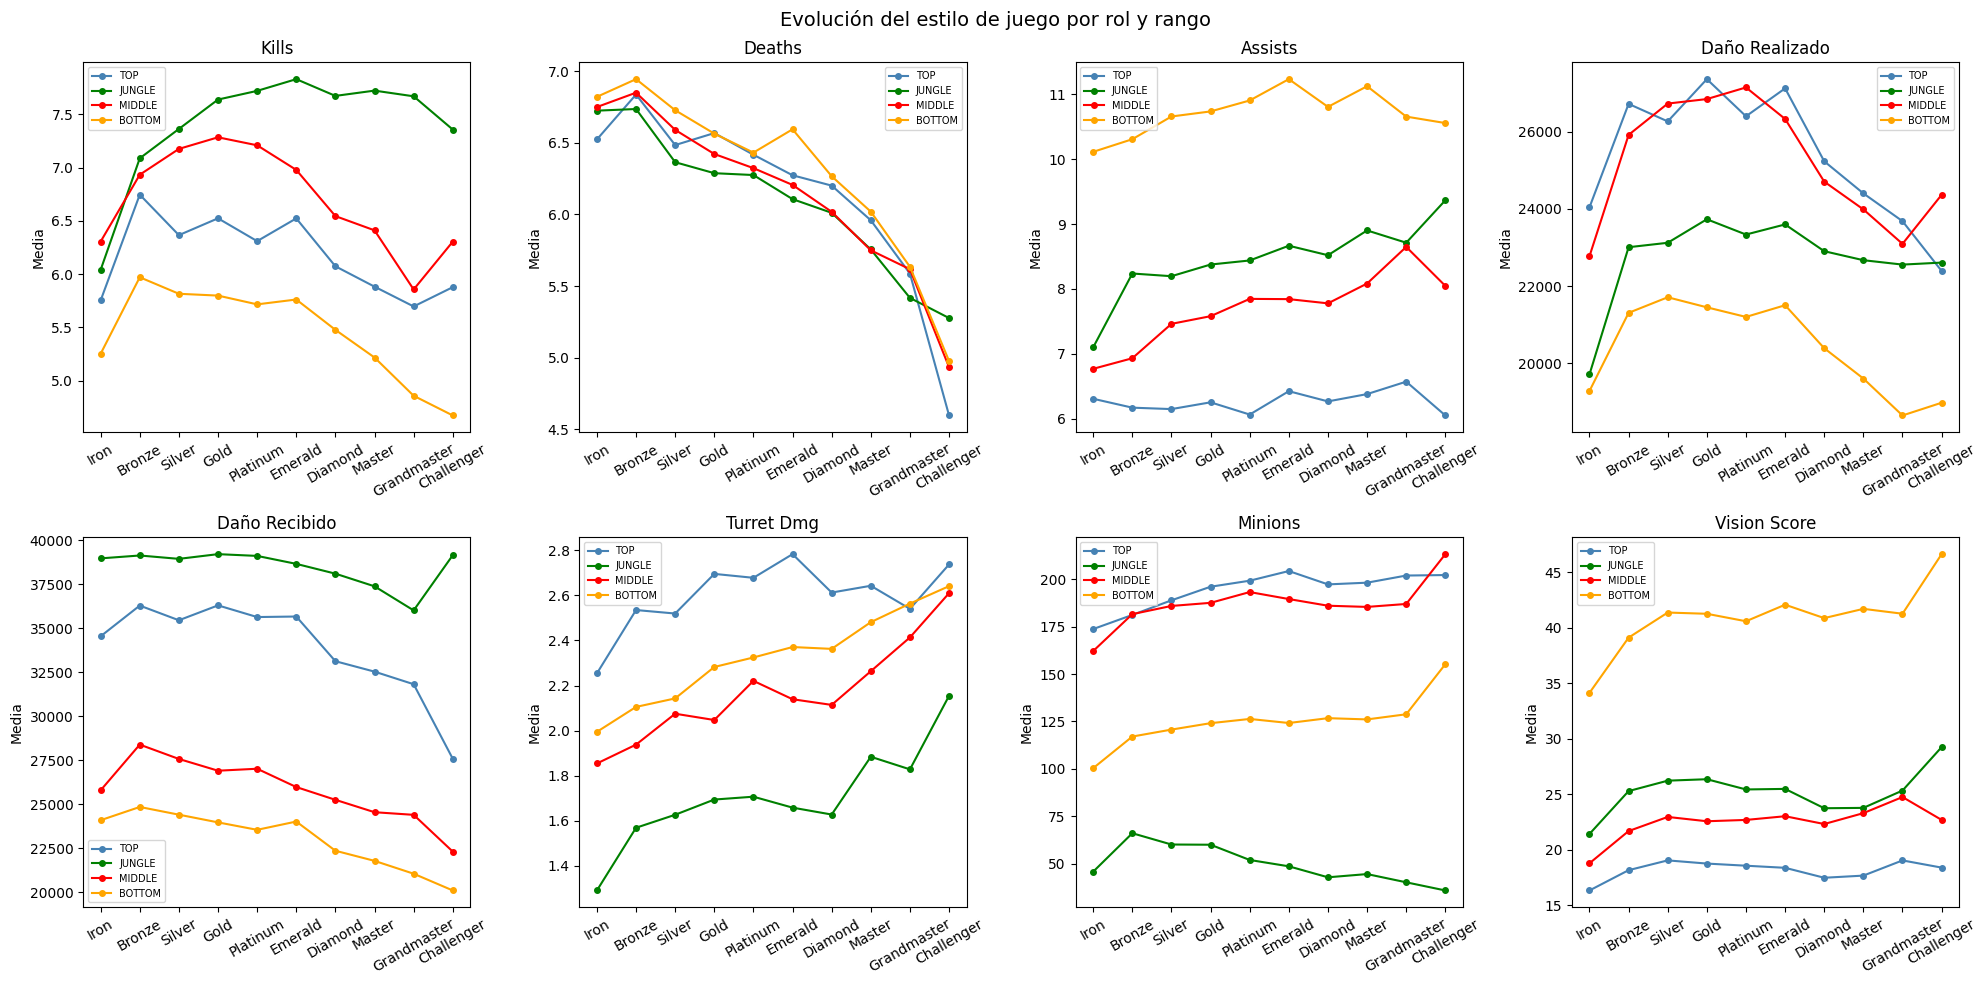

In [71]:
metrics_style = {
    "kills": "Kills",
    "deaths": "Deaths", 
    "assists": "Assists",
    "DmgDealt": "Daño Realizado",
    "DmgTaken": "Daño Recibido",
    "TurretDmgDealt": "Turret Dmg",
    "MinionsKilled": "Minions",
    "visionScore": "Vision Score"
}

role_rank_means = role_rank_df.groupby(["Lane", "RankName"])[list(metrics_style.keys())].mean()

roles = ["TOP", "JUNGLE", "MIDDLE", "BOTTOM"]
role_colors = {"TOP": "steelblue", "JUNGLE": "green", "MIDDLE": "red", "BOTTOM": "orange"}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (metric, label) in zip(axes_flat, metrics_style.items()):
    for role in roles:
        values = [role_rank_means.loc[(role, rank), metric] for rank in rank_order]
        ax.plot(rank_order, values, marker="o", label=role, color=role_colors[role], markersize=4)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("Media")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=7)

fig.suptitle("Evolución del estilo de juego por rol y rango", fontsize=14)
plt.tight_layout()

Podemos ver para cada estadística cómo varia por el rango. Los más interesantes son:
- *Minions*: Podemos ver que va subiendo cada vez más para los 3 roles "Top", "Mid" y "Bottom". sin embargo, baja para la jungla.
    - Esto tiene sentido ya que los jugadores mejores fallan menos *Last Hits* (matan más minions) y los junglas, conforme sube el nivel de juego, toman un rol más activo y de apoyo a los otros roles en la partida.
- *Vision Score*. Aumenta sobre todo en rangos altos para "Bottom" y "Jungle" ya que toman ese rol más de apoyo conforme sube el nivel.
- Todas las estadísticas de combate (Kills, Muertes, Daño realizado/recibido) bajan bastante en rangos altos para todos los roles.
    - Esto ya lo habías confirmado anteriormente, donde comentabamos que en rangos más altos el combate se reserva para conseguir objetivos.